#### **PROYEK KLASIFIKASI GAMBAR - Cat and Dog Dataset**

Proyek ini bertujuan untuk mengklasifikasikan gambar kucing dan anjing menggunakan dataset Cat and Dog dari Kaggle. Pendekatan yang digunakan adalah Transfer Learning dengan model pre-trained MobileNetV2.

**Kriteria Proyek:**
1.  Menggunakan dataset Cat and Dog dari Kaggle (>10.000 gambar).
2.  Dataset diakses langsung di Colab tanpa manual download di PC.
3.  Dataset dibagi menjadi **Train Set, Validation Set, dan Test Set**.
4.  Menggunakan struktur loading data via `ImageDataGenerator` dari direktori.
5.  Menggunakan pendekatan Transfer Learning dengan base model.
6.  Model Sequential harus menambahkan layer **Conv2D dan Pooling Layer** secara eksplisit.
7.  Klasifikasi dilakukan terhadap minimal 2 kelas gambar (kucing dan anjing).
8.  Target akurasi tinggi pada tugas klasifikasi biner ini.
9.  Membuat plot akurasi dan loss model selama pelatihan.
10. Menyimpan model dalam format SavedModel, TF-Lite, dan TFJS.
11. Semua kode berjalan secara runtut dan sistematis.

## **Setup Colab dan Data Loading**

Sesi ini mempersiapkan, menginstal library yang dibutuhkan, dan mengunduh dataset dari Kaggle.

**Instalasi Library yang Dibutuhkan**

Instal library `kaggle` untuk mengunduh dataset dan `tensorflowjs` untuk konversi model. `matplotlib`, `requests`, dan `Pillow` juga diinstal untuk kebutuhan visualisasi dan pemrosesan gambar.

In [23]:
!pip install kaggle tensorflowjs matplotlib requests Pillow

**Konfigurasi Kaggle**

Bagian ini mengkonfigurasi API Kaggle agar Colab dapat mengakses dataset dari akun Kaggle Anda. Pastikan Anda telah mengunggah `kaggle.json` yang berisi kredensial API Anda ke dalam sesi Colab.

In [24]:
# Buat direktori
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

**Unduh Dataset**


Mengunduh dan mengekstrak dataset langsung.

In [25]:
# Hapus folder sampel bawaan jika ada
!rm -r cat_dog_kaggle_data || true

In [26]:
# Nama dataset di Kaggle
KAGGLE_DATASET_NAME = 'tongpython/cat-and-dog'

In [27]:
import os
DATA_DIR = '/content/cat_dog_kaggle_data'
os.makedirs(DATA_DIR, exist_ok=True)

In [28]:
# Unduh dan ekstrak file zip dataset
!kaggle datasets download -d {KAGGLE_DATASET_NAME} -p {DATA_DIR} --unzip

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0


**Import Library**

Mengimpor library Python yang akan digunakan untuk pemrosesan data, pembangunan model, pelatihan, dan evaluasi.

In [29]:
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import shutil
import random

**Parameter Gambar dan Batch Size**

Menetapkan ukuran gambar yang akan digunakan untuk pelatihan model dan ukuran batch untuk proses training dan inferensi.

In [30]:
# Parameter Gambar dan Batch Size
IMG_WIDTH = 150
IMG_HEIGHT = 150
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
BATCH_SIZE = 32
NUM_CLASSES = 1

print(f"Image Size: {IMG_HEIGHT}x{IMG_WIDTH}")

Image Size: 150x150


## **Data Splitting**

Dataset dari Kaggle sudah terbagi menjadi `training_set` dan `test_set`. Kita perlu membagi dataset menjadi 3 bagian: Train, Validation, dan Test. Kita akan menggunakan folder `test_set` yang sudah ada sebagai final test set, dan membagi folder `training_set` yang ada menjadi train dan validation set baru.

Struktur folder:
```bash
`/content/cat_dog_split_data/train/cats`
`/content/cat_dog_split_data/train/dogs`
`/content/cat_dog_split_data/validation/cats`
`/content/cat_dog_split_data/validation/dogs`
`/content/cat_dog_split_data/test/cats`
`/content/cat_dog_split_data/test/dogs`
```

In [31]:
# Menentukan jalur untuk set data asli dan baru
base_dir = DATA_DIR
original_train_dir = os.path.join(base_dir, 'training_set', 'training_set')
original_test_dir = os.path.join(base_dir, 'test_set', 'test_set')

In [32]:
# Tentukan direktori dasar baru untuk data yang dipisahkan
split_base_dir = '/content/cat_dog_split_data'
os.makedirs(split_base_dir, exist_ok=True)

In [33]:
# Tentukan jalur untuk rangkaian pelatihan, validasi, dan uji coba baru
train_dir = os.path.join(split_base_dir, 'train')
validation_dir = os.path.join(split_base_dir, 'validation')
test_dir = os.path.join(split_base_dir, 'test')

In [34]:
# Hapus direktori output sebelumnya jika ada untuk menghindari duplikasi atau error
if os.path.exists(train_dir): shutil.rmtree(train_dir)
if os.path.exists(validation_dir): shutil.rmtree(validation_dir)
if os.path.exists(test_dir): shutil.rmtree(test_dir)

In [35]:
# Membuat direktori baru untuk melatih, validasi, dan set pengujian dengan subdirektori kelas
for dir_path in [train_dir, validation_dir, test_dir]:
    os.makedirs(os.path.join(dir_path, 'cats'), exist_ok=True)
    os.makedirs(os.path.join(dir_path, 'dogs'), exist_ok=True)

In [36]:
def split_data(source_dir, train_dest_dir, val_dest_dir, split_size):
    files = []
    for file in os.listdir(source_dir):
        file_path = os.path.join(source_dir, file)
        if os.path.isfile(file_path) and os.path.getsize(file_path) > 0:
            files.append(file)
    random.shuffle(files)
    train_size = int(len(files) * split_size)
    train_files = files[:train_size]
    validation_files = files[train_size:]

    print(f"Copying {len(train_files)} files to {train_dest_dir}")
    for file in train_files:
        shutil.copyfile(os.path.join(source_dir, file), os.path.join(train_dest_dir, file))

    print(f"Copying {len(validation_files)} files to {val_dest_dir}")
    for file in validation_files:
        shutil.copyfile(os.path.join(source_dir, file), os.path.join(val_dest_dir, file))

In [37]:
# Split original training set (cats)
split_size = 0.8  # 80% for training, 20% for validation
print("Splitting original training set (cats) into new train/validation...")
split_data(os.path.join(original_train_dir, 'cats'), os.path.join(train_dir, 'cats'), os.path.join(validation_dir, 'cats'), split_size)

Splitting original training set (cats) into new train/validation...
Copying 3200 files to /content/cat_dog_split_data/train/cats
Copying 801 files to /content/cat_dog_split_data/validation/cats


In [38]:
# Split original training set (dogs)
print("\nSplitting original training set (dogs) into new train/validation...")
split_data(os.path.join(original_train_dir, 'dogs'), os.path.join(train_dir, 'dogs'), os.path.join(validation_dir, 'dogs'), split_size)


Splitting original training set (dogs) into new train/validation...
Copying 3204 files to /content/cat_dog_split_data/train/dogs
Copying 802 files to /content/cat_dog_split_data/validation/dogs


In [39]:
# Copy original test set (cats)
print("\nCopying original test set (cats) to new test directory...")
source_cats_test = os.path.join(original_test_dir, 'cats')
dest_cats_test = os.path.join(test_dir, 'cats')
for file in os.listdir(source_cats_test):
     file_path = os.path.join(source_cats_test, file)
     if os.path.isfile(file_path) and os.path.getsize(file_path) > 0:
         shutil.copyfile(file_path, os.path.join(dest_cats_test, file))
print(f"Copied {len(os.listdir(dest_cats_test))} files to {dest_cats_test}")


Copying original test set (cats) to new test directory...
Copied 1012 files to /content/cat_dog_split_data/test/cats


In [40]:
# Copy original test set (dogs)
print("\nCopying original test set (dogs) to new test directory...")
source_dogs_test = os.path.join(original_test_dir, 'dogs')
dest_dogs_test = os.path.join(test_dir, 'dogs')
for file in os.listdir(source_dogs_test):
    file_path = os.path.join(source_dogs_test, file)
    if os.path.isfile(file_path) and os.path.getsize(file_path) > 0:
         shutil.copyfile(file_path, os.path.join(dest_dogs_test, file))
print(f"Copied {len(os.listdir(dest_dogs_test))} files to {dest_dogs_test}")


Copying original test set (dogs) to new test directory...
Copied 1013 files to /content/cat_dog_split_data/test/dogs


## **Data Augmentation**

Setelah dataset dibagi, kita menggunakan `ImageDataGenerator` untuk melakukan augmentasi data pada training set (agar model lebih robust) dan hanya melakukan rescale pada validation dan test set. `flow_from_directory` digunakan untuk memuat gambar dari struktur folder yang sudah dibuat. Penting untuk memastikan `class_mode` disetel ke 'binary' dan generator mendeteksi 2 kelas.

In [41]:
# Training Data Generator (dengan augmentasi)
train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [42]:
# Validation Data Generator (hanya rescale)
validation_image_generator = ImageDataGenerator(rescale=1./255)

In [43]:
# Test Data Generator (hanya rescale)
test_image_generator = ImageDataGenerator(rescale=1./255)

In [44]:
# Flow data dari direktori untuk training
train_data_gen = train_image_generator.flow_from_directory(
    directory=train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 6402 images belonging to 2 classes.


In [45]:
# Flow data dari direktori untuk validation
val_data_gen = validation_image_generator.flow_from_directory(
    directory=validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 1603 images belonging to 2 classes.


In [46]:
# Flow data dari direktori untuk test
test_data_gen = test_image_generator.flow_from_directory(
    directory=test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 2023 images belonging to 2 classes.


In [47]:
# Ambil jumlah gambar dari generators untuk menghitung steps_per_epoch
total_train = train_data_gen.samples
total_validation = val_data_gen.samples
total_test = test_data_gen.samples

In [48]:
steps_per_epoch = total_train // BATCH_SIZE
validation_steps = total_validation // BATCH_SIZE
test_steps = total_test // BATCH_SIZE

In [49]:
# Tambahkan 1 langkah jika ada sisa data yang kurang dari batch_size
if total_train % BATCH_SIZE != 0: steps_per_epoch += 1
if total_validation % BATCH_SIZE != 0: validation_steps += 1
if total_test % BATCH_SIZE != 0: test_steps += 1

In [50]:
# Pastikan steps minimal 1 jika ada data (menghindari pembagian dengan nol)
if steps_per_epoch == 0 and total_train > 0: steps_per_epoch = 1
if validation_steps == 0 and total_validation > 0: validation_steps = 1
if test_steps == 0 and total_test > 0: test_steps = 1

In [51]:
print(f"\nTotal training images: {total_train}")
print(f"Total validation images: {total_validation}")
print(f"Total test images: {total_test}")
print(f"Mapping kelas (Train): {train_data_gen.class_indices}")
print(f"Mapping kelas (Validation): {val_data_gen.class_indices}")
print(f"Mapping kelas (Test): {test_data_gen.class_indices}")


Total training images: 6402
Total validation images: 1603
Total test images: 2023
Mapping kelas (Train): {'cats': 0, 'dogs': 1}
Mapping kelas (Validation): {'cats': 0, 'dogs': 1}
Mapping kelas (Test): {'cats': 0, 'dogs': 1}


## **Transfer Learning**

Menggunakan model pre-trained MobileNetV2 sebagai base model, kita akan menambahkan layer `Conv2D` dan `MaxPooling2D` secara eksplisit setelah base model dan sebelum layer klasifikasi akhir. Base model akan dibekukan pada training awal.

In [52]:
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

<ipython-input-52-08f37ad4fdf6>:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [53]:
# Bekukan base model
base_model.trainable = False

In [54]:
# Model Sequential
model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='sigmoid')
])

In [55]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,003,777 (11.46 MB)

 Trainable params: 745,793 (2.84 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Kompilasi Model**

Kompilasi model untuk menyiapkan proses pelatihan. Optimizer Adam digunakan dengan learning rate yang kecil untuk fine-tuning, loss function binary crossentropy sesuai untuk klasifikasi biner, dan metrik akurasi untuk memantau performa.

In [56]:
# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

**Callbacks**

Menggunakan callbacks untuk meningkatkan efisiensi pelatihan:
- `EarlyStopping`: Menghentikan pelatihan jika validation loss tidak membaik selama beberapa epoch (patience) dan mengembalikan bobot terbaik.
- `ModelCheckpoint`: Menyimpan model dengan akurasi validasi terbaik.
- `ReduceLROnPlateau`: Mengurangi learning rate jika validation loss berhenti menurun.

In [57]:
CHECKPOINT_DIR = 'catdog_kaggle_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
checkpoint_filepath_head = os.path.join(CHECKPOINT_DIR, 'best_model_head.keras')

In [58]:
callbacks_head = [
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True),
    ModelCheckpoint(filepath=checkpoint_filepath_head,
                    monitor='val_accuracy',
                    save_best_only=True,
                    verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)
]

## **Training**

Melatih model menggunakan data training dan memvalidasi performanya menggunakan data validation. Pada tahap awal ini, hanya layer-layer yang baru ditambahkan (termasuk Conv2D dan Pooling layer eksplisit) yang akan dilatih, sementara base model dibekukan.

In [59]:
EPOCHS_HEAD = 20
print(f"Steps per epoch: {steps_per_epoch}, Validation steps: {validation_steps}")

Steps per epoch: 201, Validation steps: 51


In [60]:
# Melatih model
history_head = model.fit(
    train_data_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_HEAD,
    validation_data=val_data_gen,
    validation_steps=validation_steps,
    callbacks=callbacks_head
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.8386 - loss: 0.3506
Epoch 1: val_accuracy improved from -inf to 0.96507, saving model to catdog_kaggle_checkpoints/best_model_head.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 204s 961ms/step - accuracy: 0.8389 - loss: 0.3502 - val_accuracy: 0.9651 - val_loss: 0.0931 - learning_rate: 1.0000e-04
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.9147 - loss: 0.2037
Epoch 2: val_accuracy did not improve from 0.96507
201/201 ━━━━━━━━━━━━━━━━━━━━ 192s 911ms/step - accuracy: 0.9147 - loss: 0.2037 - val_accuracy: 0.9538 - val_loss: 0.1138 - learning_rate: 1.0000e-04
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.9167 - loss: 0.2035
Epoch 3: val_accuracy did not improve from 0.96507
201/201 ━━━━━━━━━━━━━━━━━━━━ 183s 913ms/step - accuracy: 0.9167 - loss: 0.2035 - val_accuracy: 0.9532 - val_loss: 0.1144 - learning_rate: 1.0000e-04
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.92

In [61]:
model.load_weights(checkpoint_filepath_head)

In [62]:
# Siapkan data history untuk plotting
history_combined = history_head
epochs_range_combined = range(len(history_combined.history['accuracy']))
acc = history_combined.history['accuracy']
val_acc = history_combined.history['val_accuracy']
loss = history_combined.history['loss']
val_loss = history_combined.history['val_loss']

## **Model Evaluating**

**Plot Akurasi dan Loss**


Mengevaluasi performa model menggunakan data test set yang terpisah. Ini memberikan gambaran yang lebih realistis tentang seberapa baik model akan berkinerja pada data yang belum pernah dilihat sebelumnya.

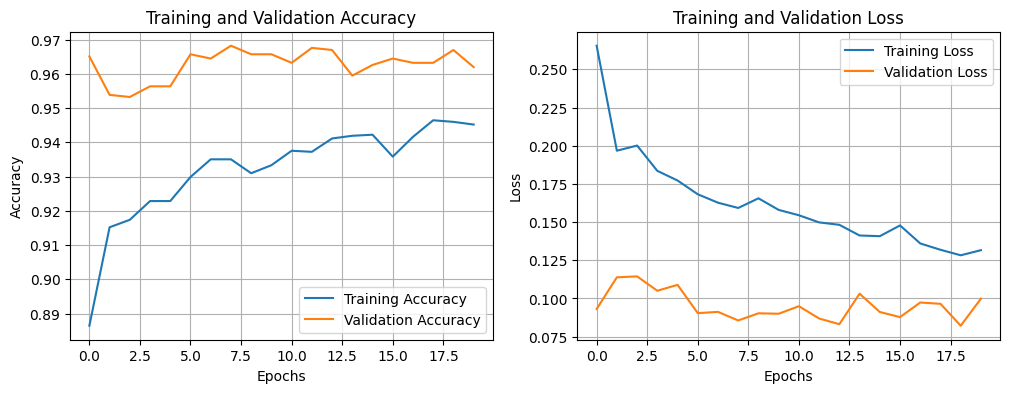

In [63]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_combined, acc, label='Training Accuracy')
plt.plot(epochs_range_combined, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(epochs_range_combined, loss, label='Training Loss')
plt.plot(epochs_range_combined, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

**Evaluasi Akhir Model**


Evaluasi model terbaik yang telah dilatih menggunakan `test_data_gen`.


In [64]:
# Evaluasi model pada data test set
loss, accuracy = model.evaluate(test_data_gen, steps=test_steps, verbose=1)
print(f"\nTest Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 568ms/step - accuracy: 0.9593 - loss: 0.1276

Test Loss: 0.09072863310575485
Test Accuracy: 0.9688581228256226


## **Saving Model**

Menyimpan model yang sudah dilatih ke dalam tiga format berbeda: SavedModel, TF-Lite, dan TFJS, sesuai dengan kriteria proyek.

In [65]:
import subprocess

MODEL_SAVE_BASE_DIR = 'catdog_kaggle_model_output'
os.makedirs(MODEL_SAVE_BASE_DIR, exist_ok=True)

# Path format model
SAVED_MODEL_DIR = os.path.join(MODEL_SAVE_BASE_DIR, 'saved_model')
TFLITE_MODEL_DIR = os.path.join(MODEL_SAVE_BASE_DIR, 'tflite_model')
TFJS_MODEL_DIR = os.path.join(MODEL_SAVE_BASE_DIR, 'tfjs_model')

In [66]:
if os.path.exists(SAVED_MODEL_DIR): shutil.rmtree(SAVED_MODEL_DIR)
if os.path.exists(TFLITE_MODEL_DIR): shutil.rmtree(TFLITE_MODEL_DIR)
if os.path.exists(TFJS_MODEL_DIR): shutil.rmtree(TFJS_MODEL_DIR)

os.makedirs(SAVED_MODEL_DIR, exist_ok=True)
os.makedirs(TFLITE_MODEL_DIR, exist_ok=True)
os.makedirs(TFJS_MODEL_DIR, exist_ok=True)

**SavedModel**

Menyimpan model dalam format SavedModel TensorFlow standar. Ini adalah format universal yang bisa digunakan untuk deployment di berbagai platform.

In [67]:
try:
    tf.saved_model.save(model, SAVED_MODEL_DIR)
    print(f"\nSavedModel: {os.path.abspath(SAVED_MODEL_DIR)}")
except Exception as e:
    print(f"\nError saving SavedModel: {e}")


SavedModel: /content/catdog_kaggle_model_output/saved_model


**TF-Lite**

Mengonversi SavedModel menjadi format TensorFlow Lite. Format ini ideal untuk deployment pada perangkat mobile dan embedded.

In [68]:
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    tflite_model = converter.convert()

    tflite_model_path = os.path.join(TFLITE_MODEL_DIR, 'model.tflite')
    with open(tflite_model_path, 'wb') as f:
        f.write(tflite_model)

    print(f"\nTF-Lite: {os.path.abspath(tflite_model_path)}")
except Exception as e:
     print(f"\nError converting to TF-Lite: {e}")


TF-Lite: /content/catdog_kaggle_model_output/tflite_model/model.tflite


**TFJS**

Mengonversi SavedModel menjadi format TensorFlow.js. Format ini memungkinkan model untuk dijalankan langsung di browser web.

In [69]:
try:
    saved_model_dir_tfjs = SAVED_MODEL_DIR

    try:
         output_node_name = model.layers[-1].name + '/' + model.layers[-1].activation.__name__
         print(f"Detected output node name: {output_node_name}")
    except Exception as e:
         print(f"Could not automatically detect output node name: {e}")
         output_node_name = 'dense_3/sigmoid'

    print(f"\nRunning tensorflowjs_converter from {os.path.abspath(saved_model_dir_tfjs)} to {os.path.abspath(TFJS_MODEL_DIR)}")
    process = subprocess.run(
        ['tensorflowjs_converter',
         '--input_format', 'tf_saved_model',
         '--output_node_names', output_node_name,
         os.path.abspath(saved_model_dir_tfjs),
         os.path.abspath(TFJS_MODEL_DIR)],
        capture_output=True,
        text=True,
        check=True
    )

    print("\nTFJS Converter Output:")
    print(process.stdout)
    if process.stderr:
        print("TFJS Converter Errors (if any):")
        print(process.stderr)

    # Verifikasi file model.json
    model_json_path = os.path.join(TFJS_MODEL_DIR, 'model.json')
    if os.path.exists(model_json_path):
        print(f"\nTFJS Conversion Successful:")
        print(f"Model saved to: {os.path.abspath(TFJS_MODEL_DIR)}")
        print(f"File model.json: {os.path.abspath(model_json_path)}")
    else:
        print("\nTFJS conversion finished, but model.json file was not found in the output directory.")


except FileNotFoundError:
     print("\nError: 'tensorflowjs_converter' command not found.")
     print("Please ensure tensorflowjs is installed in your environment ('pip install tensorflowjs').")
except subprocess.CalledProcessError as e:
     print(f"\nFailed to run tensorflowjs_converter:")
     print(f"  Command: {' '.join(e.cmd)}")
     print(f"  Return Code: {e.returncode}")
     print(f"  Stderr:\n{e.stderr}")
     print(f"  Stdout:\n{e.stdout}")
except Exception as e:
     print(f"\nAn unexpected error occurred during TFJS conversion: {e}")

Detected output node name: dense_1/sigmoid

Running tensorflowjs_converter from /content/catdog_kaggle_model_output/saved_model to /content/catdog_kaggle_model_output/tfjs_model

TFJS Converter Output:

TFJS Converter Errors (if any):
2025-05-01 15:20:17.202683: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746112817.235350   17982 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746112817.245506   17982 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
2025-05-01 15:20:26.971073: E external/local_xla/xla/stream_executor/cuda/cuda_driv

In [70]:
import os
import shutil
from google.colab import files

source_folder = '/content/cat_dog_kaggle_data'
zip_file_name = 'cat_dog_kaggle_data.zip'
zip_file_path = os.path.join('/content', zip_file_name)

if os.path.exists(source_folder):
    print(f"Compressing '{source_folder}' to '{zip_file_path}'...")
    try:
        shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', '/content', 'cat_dog_kaggle_data')

        print(f"Downloading '{zip_file_path}'...")
        files.download(zip_file_path)

    except Exception as e:
        print(f"Download Error {e}")

else:
    print(f"Error: Folder dataset '{source_folder}'")

Compressing '/content/cat_dog_kaggle_data' to '/content/cat_dog_kaggle_data.zip'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
import os
import shutil
from google.colab import files

source_folder = '/content/catdog_kaggle_checkpoints'
zip_file_name = 'catdog_kaggle_checkpoints.zip'
zip_file_path = os.path.join('/content', zip_file_name)

if os.path.exists(source_folder):
    print(f"Compressing '{source_folder}' to '{zip_file_path}'...")
    try:
        shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', '/content', 'catdog_kaggle_checkpoints')

        print(f"Downloading '{zip_file_path}'...")
        files.download(zip_file_path)

    except Exception as e:
        print(f"Download Error {e}")

else:
    print(f"Error: Folder checkpoints '{source_folder}'")

Compressing '/content/catdog_kaggle_checkpoints' to '/content/catdog_kaggle_checkpoints.zip'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
import os
import shutil
from google.colab import files

source_folder = '/content/catdog_kaggle_model_output'
zip_file_name = 'catdog_kaggle_model_output.zip'
zip_file_path = os.path.join('/content', zip_file_name)

if os.path.exists(source_folder):
    print(f"Compressing '{source_folder}' to '{zip_file_path}'...")
    try:
        shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', '/content', 'catdog_kaggle_model_output')

        print(f"Downloading '{zip_file_path}'...")
        files.download(zip_file_path)

    except Exception as e:
        print(f"Download Error {e}")

else:
    print(f"Error: Folder model output '{source_folder}'")

Compressing '/content/catdog_kaggle_model_output' to '/content/catdog_kaggle_model_output.zip'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
import os
import shutil
from google.colab import files

source_folder = '/content/cat_dog_split_data'
zip_file_name = 'cat_dog_split_data.zip'
zip_file_path = os.path.join('/content', zip_file_name)

if os.path.exists(source_folder):
    print(f"Compressing '{source_folder}' to '{zip_file_path}'...")
    try:
        shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', '/content', 'cat_dog_split_data')

        print(f"Downloading '{zip_file_path}'...")
        files.download(zip_file_path)

    except Exception as e:
        print(f"Download Error {e}")

else:
    print(f"Error: Folder dataset '{source_folder}'")

Compressing '/content/cat_dog_split_data' to '/content/cat_dog_split_data.zip'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>